<a href="https://colab.research.google.com/github/eightTT/NeRF-for-multi-view-3D-reconstruction/blob/main/3D_NeRF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recreating NeRF
This is a PyTorch implementation based on the paper: https://arxiv.org/abs/2003.08934. The code takes mostly after the officially tiny nerf implementation: https://colab.research.google.com/github/bmild/nerf/blob/master/tiny_nerf.ipynb

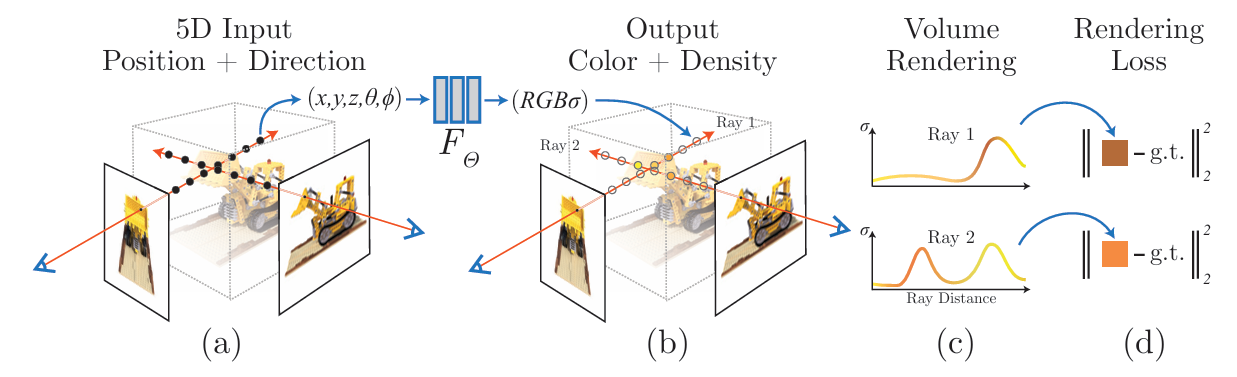

## Imports + Data


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.init as init
import time
import numpy as np
import torch.nn.functional as F
import os
from tqdm import tqdm
from ipywidgets import interactive, widgets
from PIL import Image
# import pillow_heif
import cv2

from google.colab import drive
drive.mount('/content/drive')

# Define paths
base_drive_path = "/content/drive/MyDrive/NeRF"
video_path = os.path.join(base_drive_path, "video.MOV")
frames_path = os.path.join(base_drive_path, "frames") #frames extract from video
jpg_frames_path = os.path.join(base_drive_path, "vid_frames") #image converted
data_download_path = os.path.join(base_drive_path, "tiny_nerf_data")
model_result_path = os.path.join(base_drive_path, "model_results")


os.makedirs(data_download_path, exist_ok=True)
os.makedirs(model_result_path, exist_ok=True)

if not os.path.exists(os.path.join(data_download_path, 'tiny_nerf_data.npz')):
  !wget -O {os.path.join(data_download_path, 'tiny_nerf_data.npz')} http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz
  print(f"tiny_nerf_data.npz downloaded to '{data_download_path}'.")
else:
  print(f"tiny_nerf_data.npz Already downloaded.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
tiny_nerf_data.npz Already downloaded.


## Encoding + Model

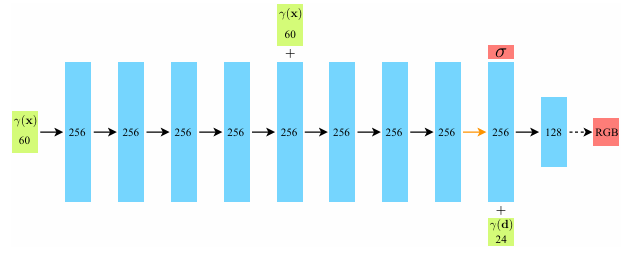

$$\gamma(p) = (\sin(2^0\pi p), \cos(2^0\pi p), \dots, \sin(2^{L-1}\pi p), \cos(2^{L-1}\pi p))$$

In [ ]:
class NeRF(nn.Module):
  def __init__(self, pos_enc_dim=63, view_enc_dim=27, hidden=256) -> None:
     super().__init__()

     self.linear1 = nn.Sequential(nn.Linear(pos_enc_dim,hidden),nn.ReLU())

     self.pre_skip_linear = nn.Sequential()
     for _ in range(4):
      self.pre_skip_linear.append(nn.Linear(hidden,hidden))
      self.pre_skip_linear.append(nn.ReLU())

     self.linear_skip = nn.Sequential(nn.Linear(pos_enc_dim+hidden,hidden),nn.ReLU())

     self.post_skip_linear = nn.Sequential()
     for _ in range(2):
      self.post_skip_linear.append(nn.Linear(hidden,hidden))
      self.post_skip_linear.append(nn.ReLU())

     self.density_layer = nn.Sequential(nn.Linear(hidden,1),nn.ReLU())

     self.linear2 = nn.Linear(hidden,hidden)

     self.color_linear1 = nn.Sequential(nn.Linear(hidden+view_enc_dim,hidden//2),nn.ReLU())
     self.color_linear2 = nn.Sequential(nn.Linear(hidden//2,3),nn.Sigmoid())

  def forward(self, input):

    positions = input[...,:3]
    view_dirs = input[...,3:]

    # Encode
    pos_enc = encoding(positions,L=10)
    view_enc = encoding(view_dirs,L=4)

    x = self.linear1(pos_enc)
    x = self.pre_skip_linear(x)

    # Skip connection
    x = torch.cat([x,pos_enc],dim=-1)
    x = self.linear_skip(x)

    x = self.post_skip_linear(x)

    # Density
    sigma = self.density_layer(x)

    x = self.linear2(x)

    # View Encoding
    x = torch.cat([x,view_enc],dim=-1)
    x = self.color_linear1(x)

    # Color Prediction
    rgb = self.color_linear2(x)

    return torch.cat([sigma,rgb],dim=-1)



def encoding(x, L=10):
  '''
  encode function
  '''
  res = [x]
  for i in range(L):
    for fn in [torch.sin, torch.cos]:
      res.append(fn(2 ** i * torch.pi * x))
  return torch.cat(res,dim=-1)

x = torch.Tensor([3.1, 5.6, 7.3])
print("Test encode with:")
y = encoding(x, L=4)
print(y.shape)

Test encode with:
torch.Size([27])


## Get Ray + Render

In [ ]:
def get_rays(H, W, focal, c2w):
  """
  Generate rays for a given camera configuration.

  Args:
    H: Image height.
    W: Image width.
    focal: Focal length.
    c2w: Camera-to-world transformation matrix (4x4).

  Returns:
    rays_o: Ray origins (H*W, 3).
    rays_d: Ray directions (H*W, 3).
  """
  device = c2w.device  # Get the device of c2w
  focal = torch.from_numpy(focal).to(device)
  # print(type(H), type(W), type(focal), type(c2w))

  i, j = torch.meshgrid(
      torch.arange(W, dtype=torch.float32, device=device),
      torch.arange(H, dtype=torch.float32, device=device),
      indexing='xy'
  )
  dirs = torch.stack(
      [(i - W * .5) / focal, -(j - H * .5) / focal, -torch.ones_like(i, device = device)], -1
  )

  rays_d = torch.sum(dirs[..., None, :] * c2w[:3, :3], -1)
  rays_d = rays_d.view(-1, 3)
  rays_o = c2w[:3, -1].expand(rays_d.shape)

  return rays_o, rays_d

def render_rays(network_fn, rays_o, rays_d, near, far, N_samples, device, rand=False, embed_fn=None, chunk=1024*4):
    def batchify(fn, chunk):
        return lambda inputs: torch.cat([fn(inputs[i:i+chunk]) for i in range(0, inputs.shape[0], chunk)], 0)

    # Sampling
    z_vals = torch.linspace(near, far, steps=N_samples, device=device)

    if rand:
        z_vals += torch.rand(*z_vals.shape[:-1], N_samples, device=rays_o.device) * (far - near) / N_samples

    pts = rays_o[...,None,:] + rays_d[...,None,:] * z_vals[...,:,None]

    # Normalize view directions
    view_dirs = rays_d / torch.norm(rays_d, dim=-1, keepdim=True)
    view_dirs = view_dirs[..., None, :].expand(pts.shape)

    input_pts = torch.cat((pts, view_dirs), dim=-1)
    raw = batchify(network_fn, chunk)(input_pts)

    # Apply activations here instead of in network
    sigma_a = raw[...,0]  # Shape: [batch, N_samples]
    rgb = raw[...,1:]    # Shape: [batch, N_samples, 3]

    # Improved volume rendering
    dists = z_vals[..., 1:] - z_vals[..., :-1]  # Shape: [batch, N_samples-1]
    dists = torch.cat([dists, torch.tensor([1e10], device=device)], -1)

    # No need to manually expand dists as broadcasting will handle it
    alpha = 1. - torch.exp(-sigma_a * dists)  # Shape: [batch, N_samples]
    alpha = alpha.unsqueeze(-1)  # Shape: [batch, N_samples, 1]

    # Computing transmittance
    ones_shape = (alpha.shape[0], 1, 1)
    T = torch.cumprod(
        torch.cat([
            torch.ones(ones_shape, device=device),
            1. - alpha + 1e-10
        ], dim=1),
        dim=1
    )[:, :-1]  # Shape: [batch, N_samples, 1]

    weights = alpha * T  # Shape: [batch, N_samples, 1]

    # Compute final colors and depths
    rgb_map = torch.sum(weights * rgb, dim=1)  # Sum along sample dimension
    depth_map = torch.sum(weights.squeeze(-1) * z_vals, dim=-1)  # Shape: [batch]
    acc_map = torch.sum(weights.squeeze(-1), dim=-1)  # Shape: [batch]

    return rgb_map, depth_map, acc_map

## Train Loop

In [ ]:
from datetime import datetime, timedelta
import json
import time

def save_model (model, metadata, save_dir = model_result_path):
    time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename = f"model_{time}.pt"
    save_path = os.path.join(save_dir, filename)

    torch.save(model.state_dict(), save_path)
    print(f"Model saved at: {save_path}")

    # Save metadata as JSON
    metadata_filename = f"metadata_{time}.json"
    metadata_path = os.path.join(save_dir, metadata_filename)
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=4)
        print(f"Metadata saved to {metadata_path}")


def train(images,poses,H,W,focal,testpose,testimg,device):

    start_time = time.time()

    print(f"Using device: {device}")
    model = NeRF().to(device)

    criterion = nn.MSELoss(reduction='mean')
    optimizer = torch.optim.Adam(model.parameters(),lr=5e-4)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)

    n_iter = 1000
    n_samples = 64
    i_plot = 50
    psnrs = []
    iternums = []
    t = time.time()

    # Convert data to tensors and move to device ONCE
    images_tensor = torch.from_numpy(images).float().to(device)
    poses_tensor = torch.from_numpy(poses).float().to(device)

    for i in range(n_iter):

        img_i = np.random.randint(images.shape[0])

        target = images_tensor[img_i]  # Use the corresponding image
        pose = poses_tensor[img_i]     # Use the corresponding pose

        rays_o, rays_d = get_rays(H, W, focal, pose)

        optimizer.zero_grad()

        rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=n_samples, device=device, rand=True)

        rgb = rgb.reshape(H,W,3)

        loss = criterion(rgb, target)

        loss.backward()
        optimizer.step()

        if i % i_plot == 0:
            print(f'Iteration: {i}, Loss: {loss.item():.6f}, Time: {(time.time() - t) / i_plot:.2f} secs per iter')
            t = time.time()

            with torch.no_grad():
                rays_o, rays_d = get_rays(H, W, focal, testpose)
                rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6.,
                                           N_samples=n_samples, device=device)
                rgb = rgb.reshape(H, W, 3)
                loss = criterion(rgb, testimg)
                psnr = -10. * torch.log10(loss)

                psnrs.append(psnr.item())
                iternums.append(i)

                plt.figure(figsize=(10,4))
                plt.subplot(121)
                plt.imshow(rgb.cpu().detach())
                plt.title(f'Iteration: {i}')
                plt.subplot(122)
                plt.plot(iternums, psnrs)
                plt.title('PSNR')
                plt.show()

    end_time = time.time()
    print(f"Training time: {timedelta(seconds=(end_time - start_time)/60)} mins")    # Save result
    metadata = {
        "loss_curve": psnrs,
        "iterations": iternums,
        "hyperparameters": {
            "learning_rate": 5e-4,
            "n_samples": n_samples,
            "n_iterations": n_iter,
        }
    }
    save_model(model, metadata)
    return model

## Load Data

img_shape:(106, 100, 100, 3), poses_shape:(106, 4, 4), focal:138.88887889922103


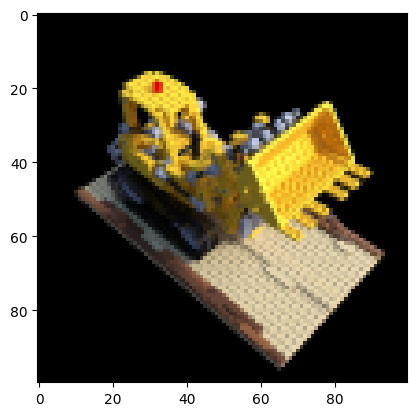

In [ ]:
data = np.load('/content/drive/MyDrive/NeRF/tiny_nerf_data/tiny_nerf_data.npz')
images = data['images']
poses = data['poses']
focal = data['focal']
H, W = images.shape[1:3]

print(f'img_shape:{images.shape}, poses_shape:{poses.shape}, focal:{focal}')

device = "cuda" if torch.cuda.is_available() else "cpu"

train_images = images[:100,...,:3] #make sure they are rgb by :3
train_poses = poses[:100]

test_img, test_pose = images[101], poses[101]
test_img =  torch.from_numpy(test_img).float().to("cuda")
test_pose = torch.from_numpy(test_pose).float().to("cuda")

# plt.imshow(test_img)
plt.imshow(test_img.cpu().detach().numpy())
plt.show()

## Train

Using device: cuda
Iteration: 0, Loss: 0.152136, Time: 0.03 secs per iter


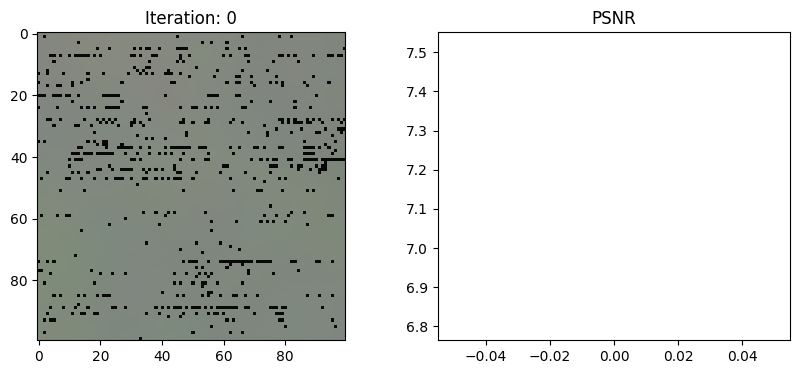

Iteration: 50, Loss: 0.102862, Time: 0.75 secs per iter


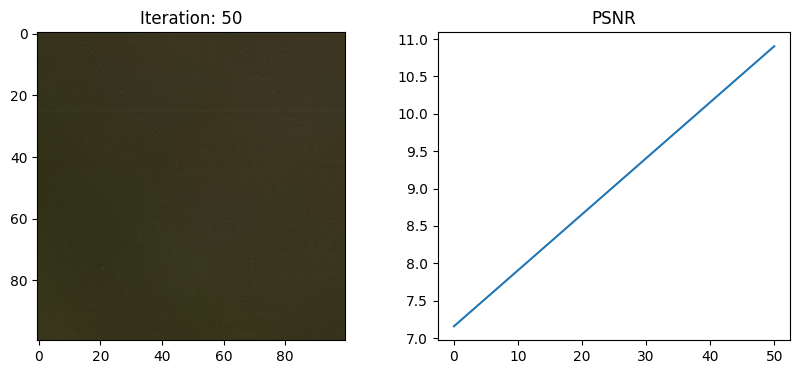

Iteration: 100, Loss: 0.070585, Time: 0.77 secs per iter


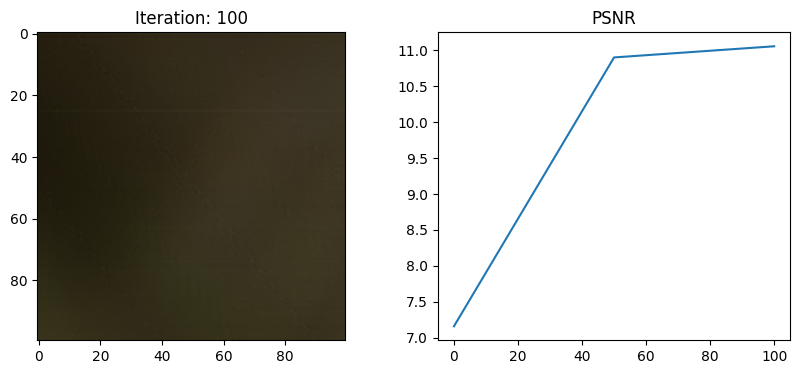

Iteration: 150, Loss: 0.072881, Time: 0.78 secs per iter


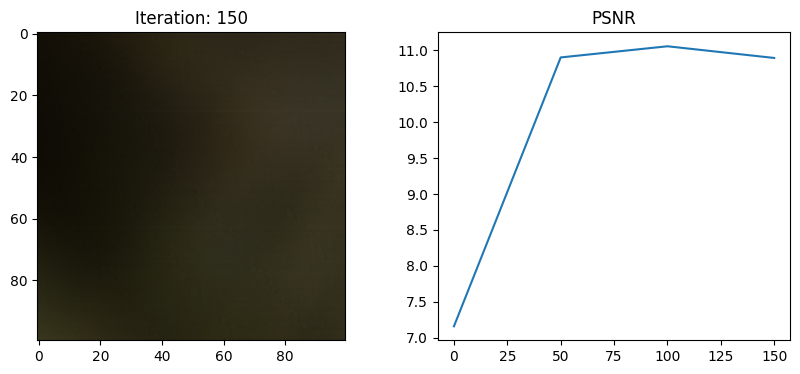

Iteration: 200, Loss: 0.048456, Time: 0.77 secs per iter


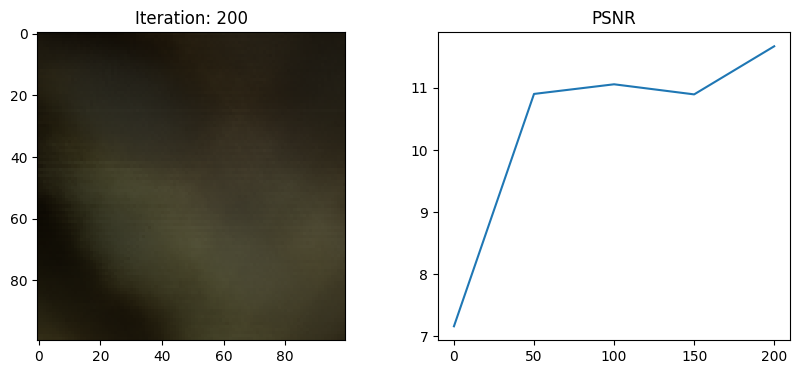

Iteration: 250, Loss: 0.026089, Time: 0.77 secs per iter


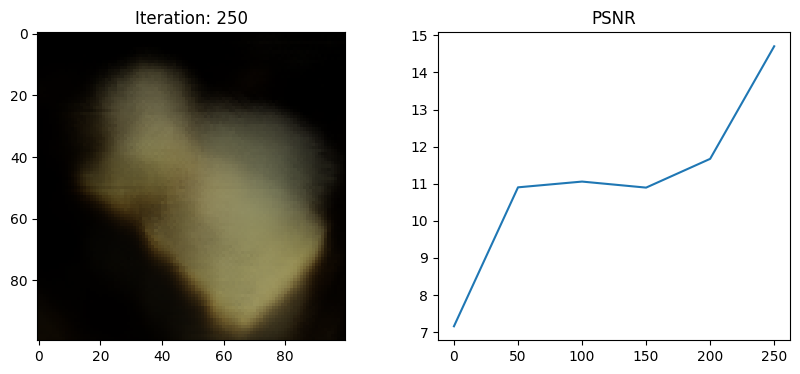

Iteration: 300, Loss: 0.020185, Time: 0.76 secs per iter


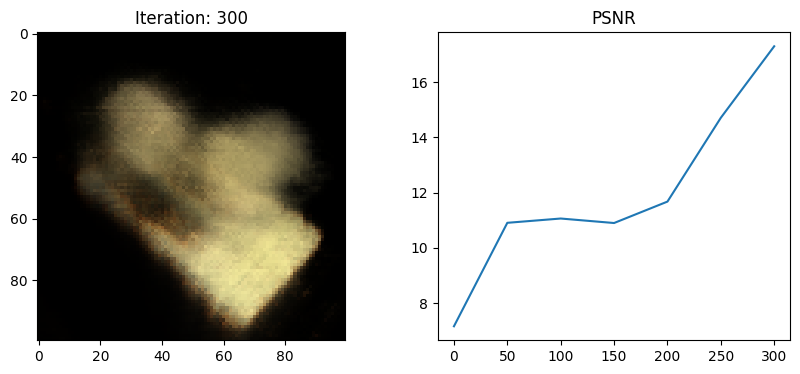

Iteration: 350, Loss: 0.015071, Time: 0.76 secs per iter


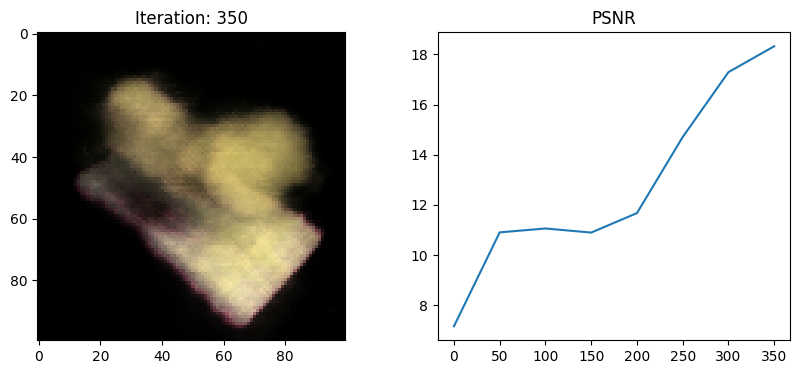

Iteration: 400, Loss: 0.009796, Time: 0.76 secs per iter


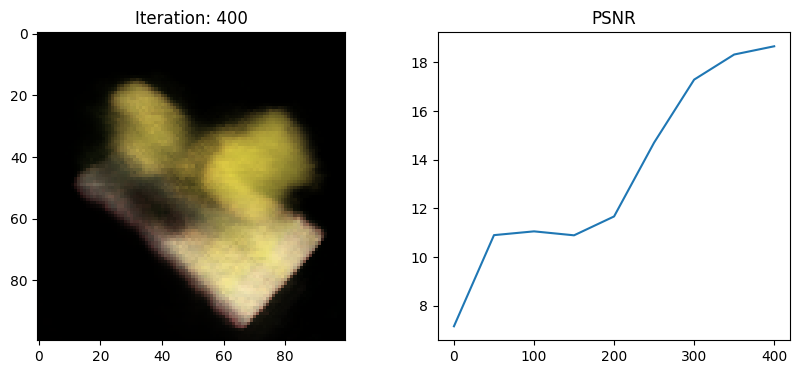

Iteration: 450, Loss: 0.008191, Time: 0.77 secs per iter


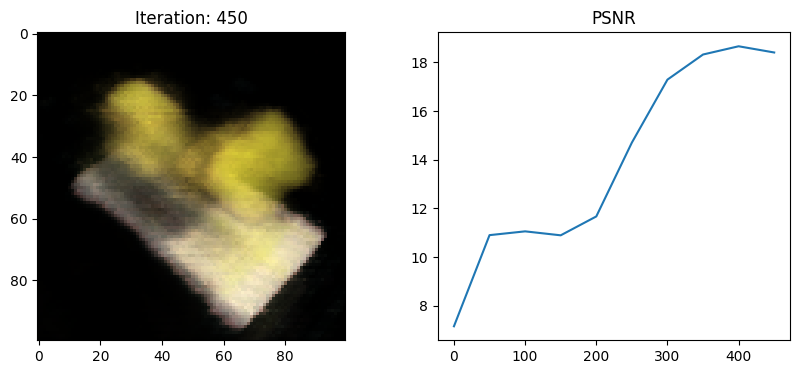

Iteration: 500, Loss: 0.012115, Time: 0.76 secs per iter


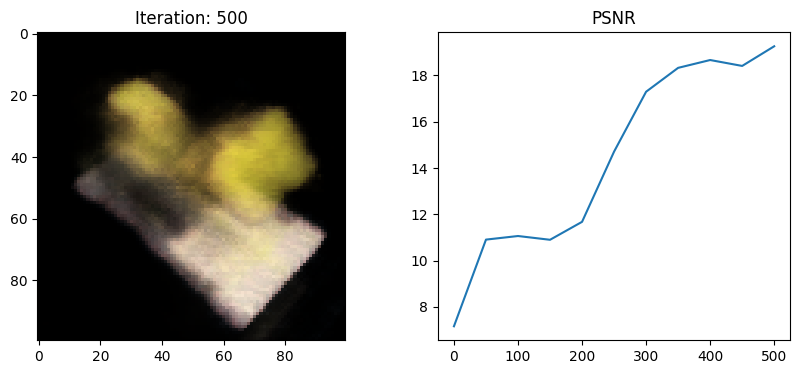

Iteration: 550, Loss: 0.009074, Time: 0.75 secs per iter


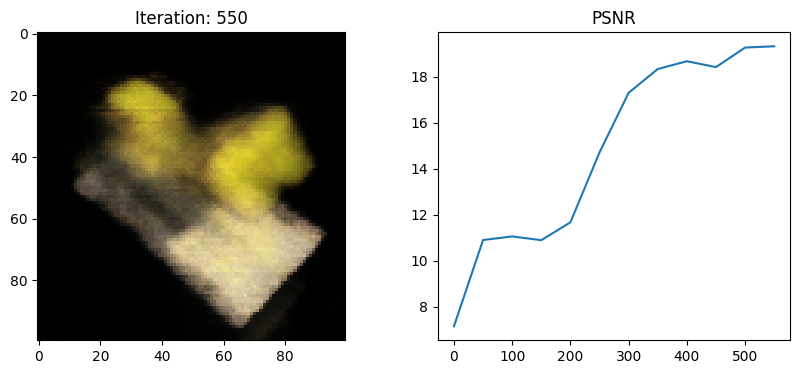

Iteration: 600, Loss: 0.012315, Time: 0.75 secs per iter


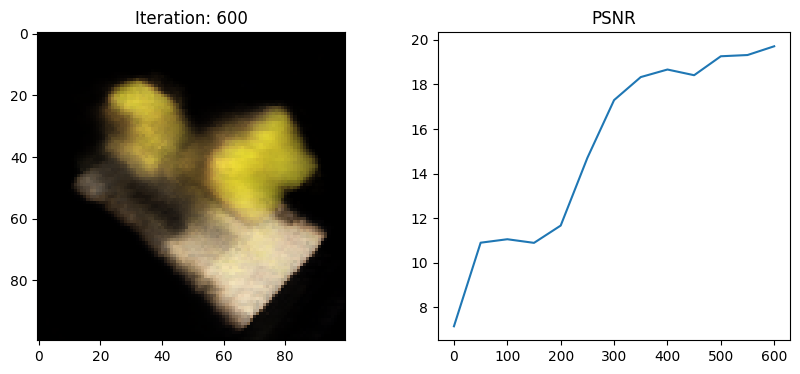

Iteration: 650, Loss: 0.010281, Time: 0.76 secs per iter


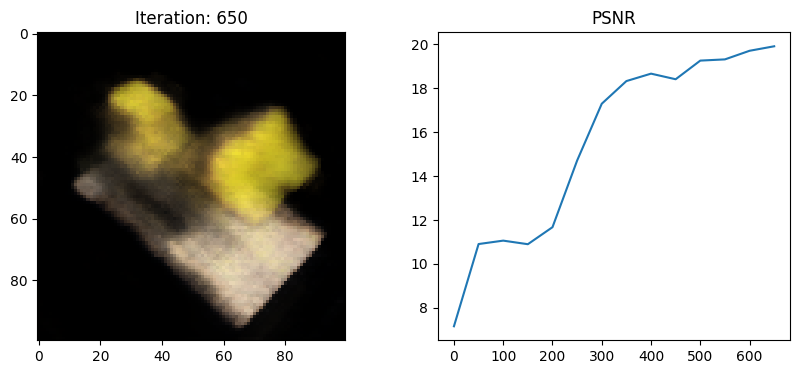

Iteration: 700, Loss: 0.006331, Time: 0.75 secs per iter


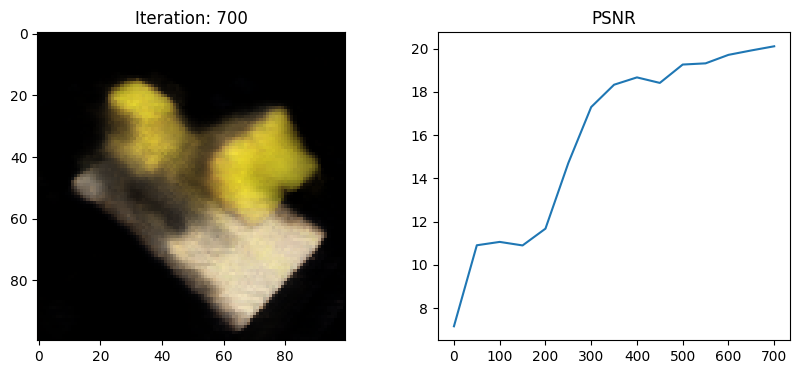

Iteration: 750, Loss: 0.008988, Time: 0.75 secs per iter


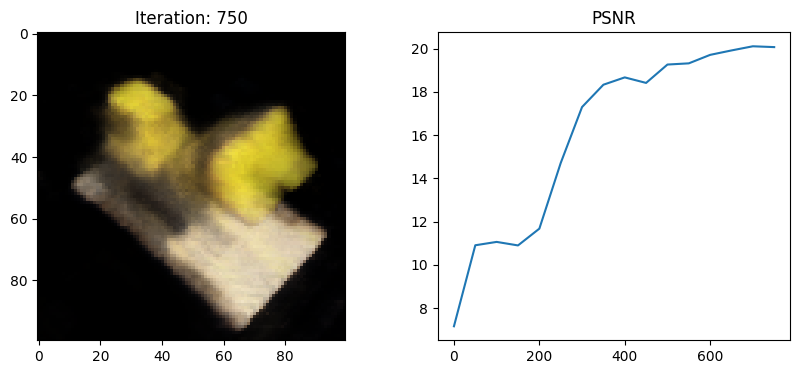

Iteration: 800, Loss: 0.008918, Time: 0.76 secs per iter


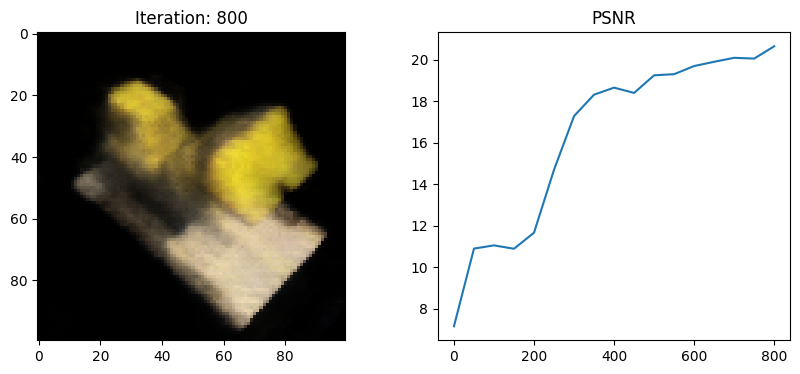

Iteration: 850, Loss: 0.011232, Time: 0.76 secs per iter


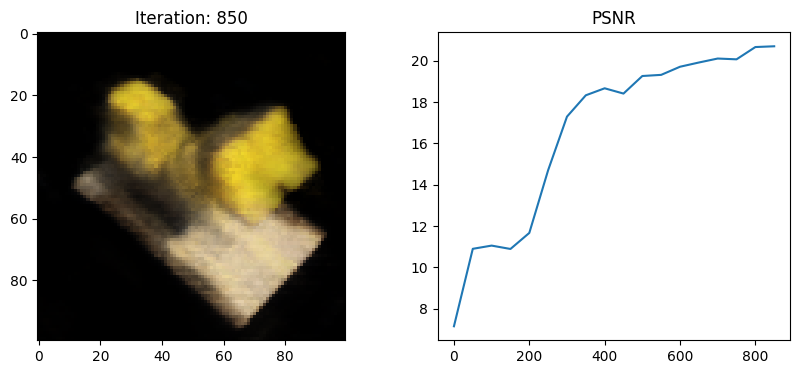

Iteration: 900, Loss: 0.011728, Time: 0.75 secs per iter


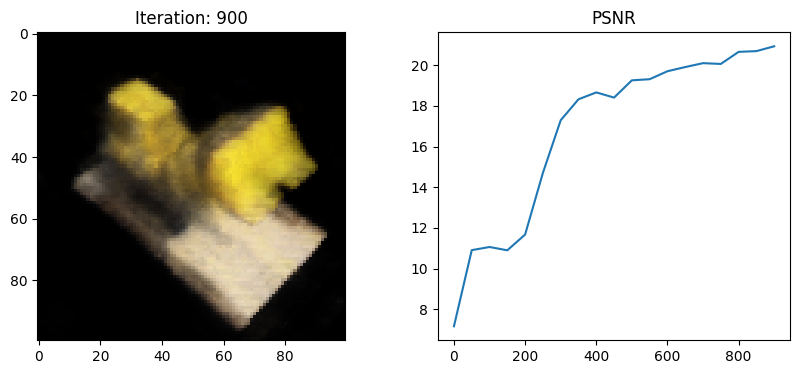

Iteration: 950, Loss: 0.004303, Time: 0.75 secs per iter


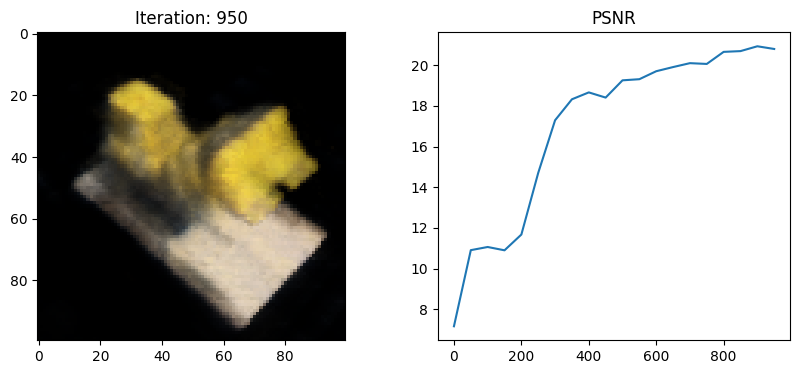

Training time: 0:00:12.719727 mins
Model saved at: /content/drive/MyDrive/NeRF/model_results/model_2025-01-01_15-20-21.pt
Metadata saved to /content/drive/MyDrive/NeRF/model_results/metadata_2025-01-01_15-20-21.json


In [ ]:
model = train(train_images, train_poses, H, W, focal, test_pose, test_img, device)

In [ ]:
# Load model
model_path = '/content/drive/MyDrive/NeRF/model_results/model_2025-01-01_15-20-21.pt'
model = NeRF()
# model.load_state_dict(torch.load(model_path,map_location=torch.device('cpu')))
model.to(device)
model.load_state_dict(torch.load(model_path))  #gpu ver
model.eval()


<ipython-input-27-b642b4ee2922>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))  #gpu ver


NeRF(
  (linear1): Sequential(
    (0): Linear(in_features=63, out_features=256, bias=True)
    (1): ReLU()
  )
  (pre_skip_linear): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
  )
  (linear_skip): Sequential(
    (0): Linear(in_features=319, out_features=256, bias=True)
    (1): ReLU()
  )
  (post_skip_linear): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
  )
  (density_layer): Sequential(
    (0): Linear(in_features=256, out_features=1, bias=True)
    (1): ReLU()
  )
  (linear2): Linear(in_features=256, out_features=256, bias=True)
  (color_linear1): Sequential(
    (0): Linear(in_feature

## Render Video

In [ ]:

'''
Synthesizes frames by iterating over interpolated camera poses.
Includes: utilities for generating camera poses, rendering, and interactive visualization.
'''
# Transformation matrices (4x4): translation along Z, rotation rounf X, Y

trans_t = lambda t: torch.tensor([        # Translation distance along the Z-axis --> 4x4 translation matrix
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, t],
    [0, 0, 0, 1]
], dtype=torch.float32)

rot_phi = lambda phi: torch.tensor([      #rotation matrix around the X-axis.
    [1, 0, 0, 0],
    [0, torch.cos(phi), -torch.sin(phi), 0],
    [0, torch.sin(phi), torch.cos(phi), 0],
    [0, 0, 0, 1]
], dtype=torch.float32)

rot_theta = lambda th: torch.tensor([     #rotation matrix around the Y-axis.
    [torch.cos(th), 0, -torch.sin(th), 0],
    [0, 1, 0, 0],
    [torch.sin(th), 0, torch.cos(th), 0],
    [0, 0, 0, 1]
], dtype=torch.float32)

# Function for rendering based on user input
def render_frame(**kwargs):
    c2w = compute_camera_pose(**kwargs)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3, :4])  # Get rays (this is a placeholder)
    c2w, rays_o, rays_d = map(lambda t: t.to(device), (c2w, rays_o, rays_d))

    # Generate RGB image using the NeRF model
    with torch.no_grad():
      rgb, _, _ = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=64, device=device)  # Render rays
    rgb  = rgb.reshape(H, W, 3).cpu().detach()
    rgb_image  = torch.clamp(rgb, 0, 1).numpy()

    # Display the result
    plt.figure(2, figsize=(20, 6))
    plt.imshow(rgb_image)
    plt.title("Rendered Frame")
    plt.show()
# Camera Pose function with spherical coordinates
def compute_camera_pose(theta, phi, radius):
    '''
    Compute camera-to-world transformation matrix (4x4).
    '''
    c2w = trans_t(radius)
    c2w = torch.matmul(rot_phi(torch.Tensor([phi / 180. * np.pi])), c2w)
    c2w = torch.matmul(rot_theta(torch.Tensor([theta / 180. * np.pi])), c2w)

    # Flip axes for correct orientation
    flip_axes = torch.tensor([
              [-1, 0, 0, 0],
              [0, 0, 1, 0],
              [0, 1, 0, 0],
              [0, 0, 0, 1]
              ], dtype=torch.float32)
    return flip_axes @ c2w

# Interactive Visualization
sldr = lambda v, mi, ma: widgets.FloatSlider(
    value=v,
    min=mi,
    max=ma,
    step=.01,
)

names = [
    ['theta', [100., 0., 360]],
    ['phi', [-30., -90, 0]],
    ['radius', [4., 3., 5.]],
]

interactive_plot = interactive(render_frame, **{s[0]: sldr(*s[1]) for s in names})
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot


interactive(children=(FloatSlider(value=100.0, description='theta', max=360.0, step=0.01), FloatSlider(value=-…

In [ ]:
frames = []
for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
    c2w = compute_camera_pose(th, -30., 4.)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3,:4])
    c2w, rays_o, rays_d = map(lambda t: t.to(device), (c2w, rays_o, rays_d))
    with torch.no_grad():
      rgb, depth, acc = render_rays(model, rays_o, rays_d, near=2., far=6., N_samples=64, device = device)
    rgb = rgb.reshape(H, W, 3)
    frames.append((255*np.clip(rgb.cpu().detach().numpy(),0,1)).astype(np.uint8))

import imageio
output_video = 'output_video1.mp4'
imageio.mimwrite(output_video, frames, fps=30, quality=7)

100%|██████████| 120/120 [00:33<00:00,  3.56it/s]


In [ ]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('output_video1.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls autoplay loop>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

# II. Reconstuct using my own images  
1.   preprocess data
2.   prepare data in NeRF format
3.   adapt model
4.   load and render



#####**1. Preprocess Data**

A set of images with corresponding camera parameters (intrinsic and extrinsic).  
1. Capture Images  
2. Camera Parameters for each image:
    *   Intrinsic,
    *   Extrinsic,
    *   Distortion coefficients

3. Undistorted and Normalize(crop) Images
4. Estimate Camera Poses each images  
5. Combine ALL images, poses, focal length to ONE .npz file.

In [ ]:
print(jpg_frames_path)

In [ ]:
#load camera matrix
#Undistort and Normalize
#Estimate CAMERA POSE
import cv2
import numpy as np
import os
import glob

def load_calibration_parameters(calibration_file):
    data = np.load(calibration_file)
    print("Complete load calibration parameters.")
    return data['camera_matrix'], data['distortion_coeffs']

def normalize_and_undistort_images(image_folder, camera_matrix, distortion_coeffs, target_size=(800, 800)):
    images = glob.glob(os.path.join(image_folder, '*.jpg'))
    processed_images = []

    for img_path in images:
        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        # Undistort the image
        new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(camera_matrix, distortion_coeffs, (w, h), 1, (w, h))
        undistorted_img = cv2.undistort(img, camera_matrix, distortion_coeffs, None, new_camera_matrix)
        x, y, w, h = roi
        undistorted_img = undistorted_img[y:y+h, x:x+w]

        # Resize and normalize
        resized_img = cv2.resize(undistorted_img, target_size)
        normalized_img = resized_img.astype(np.float32) / 255.0

        processed_images.append(normalized_img)

    print("Complete undistort & normalized.")
    return processed_images

def estimate_camera_poses(processed_images, camera_matrix):
    """
      Estimate camera poses using: SIFT feature matching, pose recovery
    """
    detector = cv2.SIFT_create()
    bf_matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

    poses = []
    poses.append(np.eye(4))  # Initial pose is identity (world frame)

    for i in range(len(processed_images) - 1):
        # Convert normalized images back to uint8 for SIFT
        img1_uint8 = (processed_images[i] * 255).astype(np.uint8)
        img2_uint8 = (processed_images[i + 1] * 255).astype(np.uint8)

        # Feature detection and matching
        kp1, des1 = detector.detectAndCompute(img1_uint8, None)
        kp2, des2 = detector.detectAndCompute(img2_uint8, None)
        matches = bf_matcher.match(des1, des2)
        matches = sorted(matches, key=lambda x: x.distance)

        # Extract matched points
        pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
        pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

        # Estimate essential matrix and pose
        E, mask = cv2.findEssentialMat(pts1, pts2, camera_matrix, method=cv2.RANSAC, prob=0.999, threshold=1.0)
        _, R, t, mask = cv2.recoverPose(E, pts1, pts2, camera_matrix)

        # Compute pose matrix [R|t]
        pose = np.eye(4)
        pose[:3, :3] = R
        pose[:3, 3] = t.squeeze()
        poses.append(poses[-1] @ pose)  # Accumulate pose transformations

        print(f"Processed pose for image pair {i} -> {i+1}")
    print("Complete pose estimation.")
    return np.array(poses)

def save_dataset(output_file, processed_images, poses, focal_length):
    np.savez(output_file, images=np.array(processed_images), poses=poses, focal_length=focal_length)
    print(f"Dataset saved to {output_file}")

def main():
    # Paths
    calibration_file = '/content/drive/MyDrive/NeRF/camera_calib/camera_calib_result.npz'
    image_folder = '/content/drive/MyDrive/NeRF/vid_frames'
    output_file = '/content/drive/MyDrive/NeRF/nerf_dataset.npz'

    # Load calibration parameters
    camera_matrix, distortion_coeffs = load_calibration_parameters(calibration_file)
    focal_length = camera_matrix[0, 0]  # Assuming fx = fy

    # Normalize and undistort images
    processed_images = normalize_and_undistort_images(image_folder, camera_matrix, distortion_coeffs)

    # Estimate camera poses
    poses = estimate_camera_poses(processed_images, camera_matrix)

    # Save the dataset
    save_dataset(output_file, processed_images, poses, focal_length)

if __name__ == '__main__':
    main()


Complete load calibration parameters.
Complete undistort & normalized.
Processed pose for image pair 0 -> 1
Processed pose for image pair 1 -> 2
Processed pose for image pair 2 -> 3
Processed pose for image pair 3 -> 4
Processed pose for image pair 4 -> 5
Processed pose for image pair 5 -> 6
Processed pose for image pair 6 -> 7
Processed pose for image pair 7 -> 8
Processed pose for image pair 8 -> 9
Processed pose for image pair 9 -> 10
Processed pose for image pair 10 -> 11
Processed pose for image pair 11 -> 12
Processed pose for image pair 12 -> 13
Processed pose for image pair 13 -> 14
Processed pose for image pair 14 -> 15
Processed pose for image pair 15 -> 16
Processed pose for image pair 16 -> 17
Processed pose for image pair 17 -> 18
Processed pose for image pair 18 -> 19
Processed pose for image pair 19 -> 20
Processed pose for image pair 20 -> 21
Processed pose for image pair 21 -> 22
Processed pose for image pair 22 -> 23
Processed pose for image pair 23 -> 24
Processed po

In [ ]:
def render_frame(model, H, W, focal, pose, device, near=2.0, far=6.0, N_samples=64):
    """Render a single frame using the NeRF model."""
    c2w = torch.tensor(pose, dtype=torch.float32, device=device)
    rays_o, rays_d = get_rays(H, W, focal, c2w[:3, :4])  # Placeholder for ray generation
    rays_o, rays_d = map(lambda t: t.to(device), (rays_o, rays_d))

    with torch.no_grad():
        rgb, _, _ = render_rays(model, rays_o, rays_d, near, far, N_samples, device=device)  # Render rays
    rgb = rgb.reshape(H, W, 3).cpu().detach()
    return torch.clamp(rgb, 0, 1).numpy()



def render_video(output_file, model, images, poses, focal, device):
    """Render a video by generating frames from NeRF model."""
    H, W = images.shape[1:3]
    rendered_frames = []

    for i, pose in tqdm(enumerate(poses), total=len(poses)):
        frame = render_frame(model, H, W, focal, pose, device)
        rendered_frames.append(frame)

    imageio.mimwrite(
        output_file,
        [(255 * np.clip(frame, 0, 1)).astype(np.uint8) for frame in rendered_frames],
        fps=30
    )
    print(f"Rendered video saved to {output_file}")


img_shape:(501, 800, 800, 3), poses_shape:(501, 4, 4), focal:3099.1891148313143


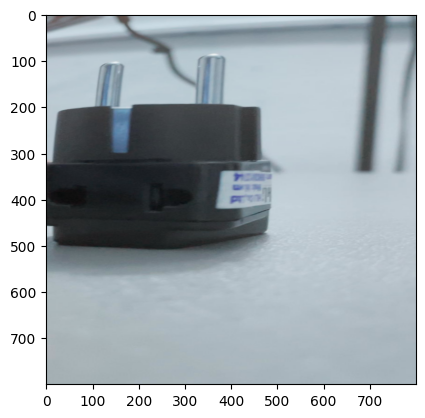

Using device: cuda


OutOfMemoryError: CUDA out of memory. Tried to allocate 256.00 MiB. GPU 0 has a total capacity of 14.75 GiB of which 65.06 MiB is free. Process 472342 has 14.68 GiB memory in use. Of the allocated memory 14.24 GiB is allocated by PyTorch, and 329.11 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import cv2
import numpy as np
import os
import glob
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import imageio
from base64 import b64encode
from IPython.display import HTML

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Load data
my_data = np.load('/content/drive/MyDrive/NeRF/nerf_dataset.npz')
images = my_data['images']
poses = my_data['poses']
focal = my_data['focal_length']
H, W = images.shape[1:3]
print(f'img_shape:{images.shape}, poses_shape:{poses.shape}, focal:{focal}')

# Load NeRF model
# model_path = '/content/drive/MyDrive/NeRF/model_results/model_2025-01-01_15-20-21.pt'
# model = NeRF()
# model.load_state_dict(torch.load(model_path, map_location=device))
# model.eval().to(device)

#split data
train_images = images[:50,...,:3]
train_poses = poses[:50]

image_test = images[51]
pose_test = poses[51]
image_test =  torch.from_numpy(image_test).float().to("cuda")
pose_test = torch.from_numpy(pose_test).float().to("cuda")
plt.imshow(image_test.cpu().detach().numpy())
plt.show()

#train
model = train(train_images, train_poses, H, W, focal, pose_test, image_test, device)

output_video_path = '/content/drive/MyDrive/NeRF/rendered_video.mp4'
render_video(output_video_path, model, images, poses, focal, device)

# Display video
mp4 = open(output_video_path, 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f"""
<video width=600 controls autoplay loop>
    <source src="{data_url}" type="video/mp4">
</video>
""")


In [ ]:
!pip install torch torchvision torchaudio sympy --upgrade
